# Lesson: GPU vs CPU Benchmark for Image Training

This notebook demonstrates a workload that favors the GPU DirectML setup over CPU.

It uses the Oxford-IIIT Pets dataset and a simple convolutional model to compare runtime.

The dataset is cached locally in `data/` so future runs reuse the same files.

In [1]:
import re, sys, os
from pathlib import Path
from dml_fastai_utils import setup_dml, get_local_path, optimize_dls
import torch_directml

In [2]:
from fastai.vision.all import *

In [3]:
# Initialize DirectML and apply global patches
dml = setup_dml()
local_data_path = get_local_path()

DIRECTML VANGUARD MODULE LOADED (v3.0)
Device: privateuseone:0
GPU: Qualcomm(R) Adreno(TM) X1-85 GPU 


## Local Dataset Cache

We save the Pets dataset into `data/` so it does not need to be downloaded again on future runs.

In [4]:
local_data_path = Path('data')
local_data_path.mkdir(parents=True, exist_ok=True)
path = Path(untar_data(URLs.PETS, data=local_data_path))
print('Dataset path:', path)

Dataset path: C:\Users\Said\.fastai\data\oxford-iiit-pet


## Build the Image DataLoaders

We use the same dataset split for both the GPU and CPU benchmarks.

DataLoaders optimized: num_workers=8, pin_memory=False


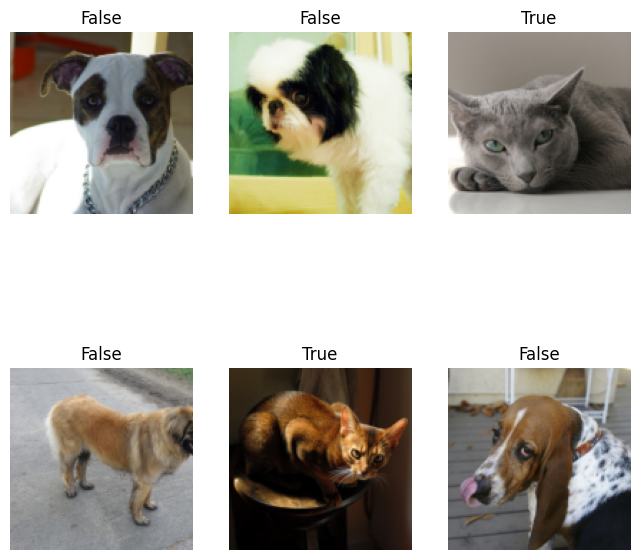

In [5]:
img_path = path/'images'
def label_func(x): return Path(x).name[0].isupper()
dls_base = ImageDataLoaders.from_name_func(
    img_path, get_image_files(img_path), label_func,
    valid_pct=0.2, seed=42,
    item_tfms=Resize(128), bs=128,
    num_workers=8
)
dls_base = optimize_dls(dls_base, num_workers=8)
dls_base.show_batch(max_n=6, figsize=(8,8))

## GPU DirectML Benchmark

Train the same ResNet model with the DirectML Adreno device and record the runtime.

In [ ]:
gpu_device = setup_dml()
dls_gpu = DataLoaders(
    dls_base.train.new(device=gpu_device),
    dls_base.valid.new(device=gpu_device),
    path=dls_base.path,
    device=gpu_device
)
learn_gpu = vision_learner(dls_gpu, resnet18, metrics=accuracy)
n_epochs = 4
start = time.perf_counter()
learn_gpu.fit_one_cycle(n_epochs, lr_max=3e-3)
gpu_time = time.perf_counter() - start
print(f'GPU DirectML elapsed: {gpu_time:.2f}s')

DIRECTML VANGUARD MODULE LOADED (v3.0)
Device: privateuseone:0
GPU: Qualcomm(R) Adreno(TM) X1-85 GPU 


c:\Users\Said\k3sh4v_practicaldeeplearningconsumergpu\.venv\Lib\site-packages\torch\amp\autocast_mode.py:265: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
c:\Users\Said\k3sh4v_practicaldeeplearningconsumergpu\.venv\Lib\site-packages\torch\amp\grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


epoch,train_loss,valid_loss,accuracy,time
0,1.302245,0.872878,0.587280,01:30
1,1.304376,0.862910,0.589986,01:30


KeyboardInterrupt: 

## CPU-only Benchmark

Run the same model on CPU to compare the total training time on the same dataset.

In [ ]:
cpu_device = torch.device('cpu')
dls_cpu = DataLoaders(
    dls_base.train.new(device=cpu_device),
    dls_base.valid.new(device=cpu_device),
    path=dls_base.path,
    device=cpu_device
)
learn_cpu = vision_learner(dls_cpu, resnet18, metrics=accuracy)
learn_cpu.to(cpu_device)
start = time.perf_counter()
learn_cpu.fit_one_cycle(n_epochs, lr_max=3e-3)
cpu_time = time.perf_counter() - start
print(f'CPU elapsed: {cpu_time:.2f}s')

In [ ]:
results = pd.DataFrame([
    {
        'setup': 'DirectML Adreno GPU',
        'duration_s': gpu_time,
        'duration_min': gpu_time/60.0,
        'notes': 'GPU path with DirectML'
    },
    {
        'setup': 'CPU-only',
        'duration_s': cpu_time,
        'duration_min': cpu_time/60.0,
        'notes': 'CPU baseline'
    }
])
results

## Benchmark Summary

If the GPU setup is faster, this notebook has demonstrated a workload where the DirectML Adreno path is beneficial.

If the CPU path is still faster, the lesson shows that small or unsupported workloads can remain CPU-bound, and a larger GPU-friendly workload should be chosen.